[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.3_quasi_experiment_figures.ipynb)

# Figures for §3.3 "Quasi Experiments"

Figure-generation notebook for the three conceptual charts in **§3.3** of
*Marketing Science in Python*. Each cell builds one figure and writes it to
`images/part3/sec3.3/`, overwriting the chapter's image referenced by the `.qmd`:

- `did_parallel_trends.png` — Difference-in-Differences: parallel pre-trends,
  then post-intervention divergence.
- `rdd_discontinuity.png` — Regression Discontinuity: a jump in the outcome at
  the treatment threshold.
- `synthetic_control.png` — Synthetic Control: actual vs. synthetic
  counterfactual.

These are illustrative charts built from small synthetic series; they do not
depend on any external dataset.

### Setup

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

save_dir = os.path.join('..', '..', 'images', 'part3', 'sec3.3')
os.makedirs(save_dir, exist_ok=True)

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## Figure 1 — Difference-in-Differences (parallel trends)

Category sales per store for pilot and comparison stores. The two groups grow in
parallel before the in-store display rolls out; afterward the pilot group rises
above the path it would have followed (the dashed counterfactual). The remaining
gap is the DiD estimate of the display's effect.

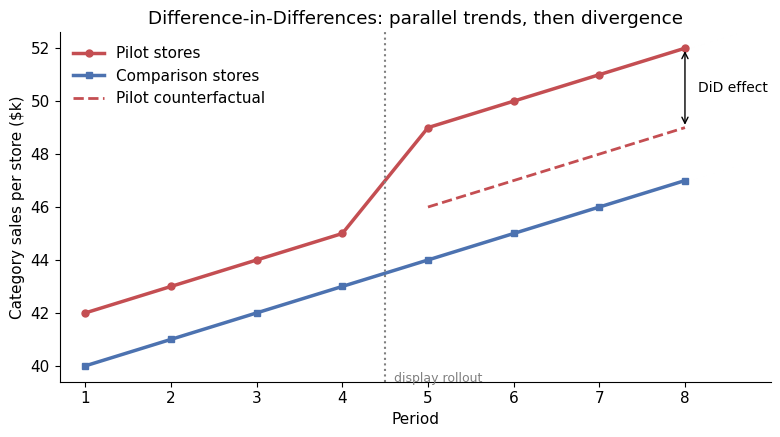

In [2]:
periods = np.arange(1, 9)          # 8 periods
intervention = 4.5                 # program launches between period 4 and 5
post = periods > intervention

control = 40 + 1.0 * (periods - 1)            # common trend, grows $1 / period
treatment_pre = control + 2.0                 # parallel, $2 above control
effect = 3.0
treatment = treatment_pre + effect * post     # post-intervention lift
counterfactual = treatment_pre                # what treatment would have been

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(periods, treatment, color='#C44E52', lw=2.5, marker='o', ms=5, label='Pilot stores')
ax.plot(periods, control, color='#4C72B0', lw=2.5, marker='s', ms=5, label='Comparison stores')
ax.plot(periods[post], counterfactual[post], color='#C44E52', lw=2, ls='--',
        label='Pilot counterfactual')

ax.axvline(intervention, color='gray', ls=':', lw=1.5)
ax.annotate('display rollout', xy=(intervention, 39.4), xytext=(intervention + 0.1, 39.4),
            fontsize=9, color='gray')

# annotate the DiD gap at the last period
ax.annotate('', xy=(periods[-1], treatment[-1]), xytext=(periods[-1], counterfactual[-1]),
            arrowprops=dict(arrowstyle='<->', color='black'))
ax.annotate('DiD effect', xy=(periods[-1], (treatment[-1] + counterfactual[-1]) / 2),
            xytext=(periods[-1] + 0.15, (treatment[-1] + counterfactual[-1]) / 2),
            fontsize=10, va='center', ha='left')

ax.set_xlim(0.7, 9.0)
ax.set_xticks(periods)
ax.set_xlabel('Period')
ax.set_ylabel('Category sales per store ($k)')
ax.set_title('Difference-in-Differences: parallel trends, then divergence')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(save_dir, 'did_parallel_trends.png'), dpi=150, bbox_inches='tight')

## Figure 2 — Regression Discontinuity (RDD)

Customers with at least $500 in pre-campaign annual spend receive a coupon.
Plotting subsequent spend against the running variable, a clear jump appears at
the cutoff: customers just above and just below are otherwise nearly identical,
so the discontinuity estimates the local treatment effect.

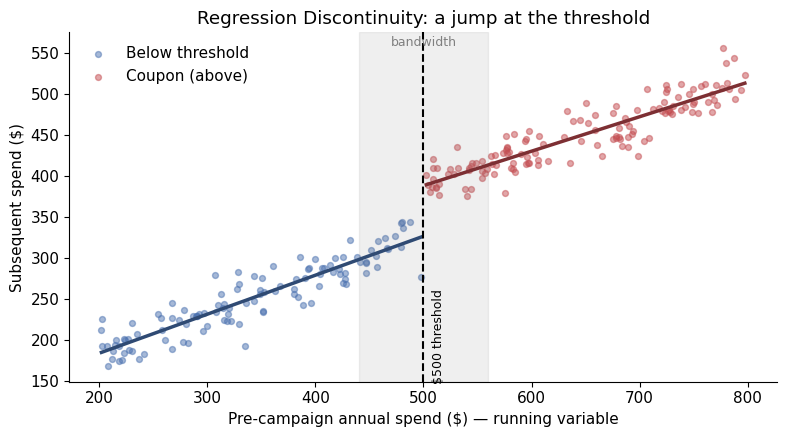

In [3]:
rng = np.random.default_rng(7)

cutoff = 500
x = rng.uniform(200, 800, 250)
treated = x >= cutoff
jump = 60
y = 100 + 0.45 * x + jump * treated + rng.normal(0, 18, x.size)

fig, ax = plt.subplots(figsize=(8, 4.5))
below, above = x < cutoff, x >= cutoff
ax.scatter(x[below], y[below], color='#4C72B0', alpha=0.5, s=18, label='Below threshold')
ax.scatter(x[above], y[above], color='#C44E52', alpha=0.5, s=18, label='Coupon (above)')

# fit and draw a regression line on each side
for mask, color in [(below, '#2f4a73'), (above, '#7d2f33')]:
    b, a = np.polyfit(x[mask], y[mask], 1)
    xs = np.linspace(x[mask].min(), x[mask].max(), 50)
    ax.plot(xs, a + b * xs, color=color, lw=2.5)

ax.axvline(cutoff, color='black', ls='--', lw=1.5)
ax.axvspan(cutoff - 60, cutoff + 60, color='gray', alpha=0.12)
ax.annotate('bandwidth', xy=(cutoff, ax.get_ylim()[1] * 0.97), ha='center',
            fontsize=9, color='gray')
ax.annotate('$500 threshold', xy=(cutoff + 8, 150), fontsize=9, rotation=90, color='black')

ax.set_xlabel('Pre-campaign annual spend ($) — running variable')
ax.set_ylabel('Subsequent spend ($)')
ax.set_title('Regression Discontinuity: a jump at the threshold')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(save_dir, 'rdd_discontinuity.png'), dpi=150, bbox_inches='tight')

## Figure 3 — Synthetic Control

A "synthetic New York" is built from a weighted mix of untreated markets to
match New York's pre-campaign sales. The two lines overlap before the
campaign; afterward the gap between actual New York and its synthetic
counterpart is the estimated treatment effect.

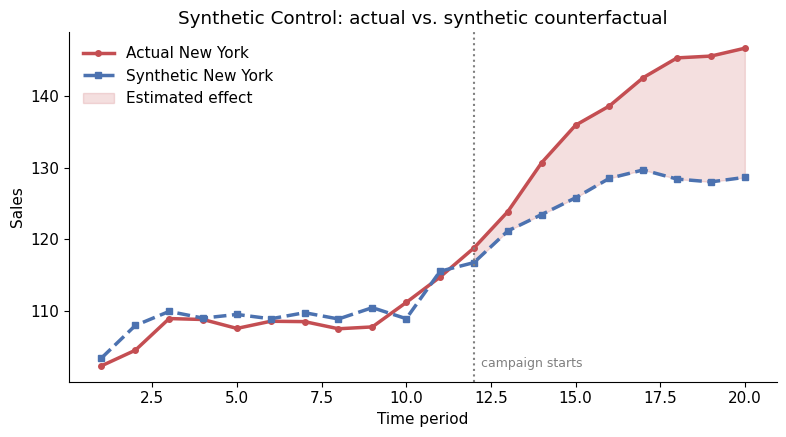

In [4]:
rng = np.random.default_rng(11)

t = np.arange(1, 21)
intervention_t = 12
common = 100 + 1.5 * t + 4 * np.sin(t / 2.0)        # shared trend + seasonality
synthetic = common + rng.normal(0, 1.2, t.size)
actual = common + rng.normal(0, 1.2, t.size)
post_t = t >= intervention_t
actual = actual + np.where(post_t, 2.2 * (t - (intervention_t - 1)), 0)  # ramping lift

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t, actual, color='#C44E52', lw=2.5, marker='o', ms=4, label='Actual New York')
ax.plot(t, synthetic, color='#4C72B0', lw=2.5, ls='--', marker='s', ms=4,
        label='Synthetic New York')
ax.fill_between(t[post_t], synthetic[post_t], actual[post_t], color='#C44E52', alpha=0.18,
                label='Estimated effect')

ax.axvline(intervention_t, color='gray', ls=':', lw=1.5)
ax.annotate('campaign starts', xy=(intervention_t, ax.get_ylim()[0] + 2),
            xytext=(intervention_t + 0.2, ax.get_ylim()[0] + 2), fontsize=9, color='gray')

ax.set_xlabel('Time period')
ax.set_ylabel('Sales')
ax.set_title('Synthetic Control: actual vs. synthetic counterfactual')
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(save_dir, 'synthetic_control.png'), dpi=150, bbox_inches='tight')

In [5]:
print('Saved figures to', save_dir)

Saved figures to images/part3/sec3.3
